In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_formats = {"retina", "png"}

# Suppress all pandas PerformanceWarnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

## Load LF + TSA merged dataset

The `scripts/bus39/transform.py` script produces merged LF+TSA dataset. Let's load the data.


In [ ]:
from src import DATA_INTERIM_PATH

assert DATA_INTERIM_PATH.exists(), DATA_INTERIM_PATH

In [ ]:
from src.utils import determine_features_and_targets

df = pd.read_pickle(DATA_INTERIM_PATH / "tsa_lf_merged.pkl.zst")
feature_cols, target_cols = determine_features_and_targets(df)

Skipped: "state"
Skipped: "experiment"
Skipped: "P_New_Load"
Skipped: "Q_New_Load"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1044797 entries, 0 to 1274688
Columns: 228 entries, state to Sk_Bus_39
dtypes: bool(44), category(3), float32(178), int32(3)
memory usage: 776.2 MB


In [ ]:
# Arbitrary value set by domain experts
CCT_THRESHOLD = 0.2

## CCT Estimation with Machine Learning


In [ ]:
import joblib
from sklearn import compose, neighbors
from sklearn import preprocessing as prep

from src.utils import TimeIt, select_centered_columns, select_positive_columns

In [ ]:
encoder = compose.make_column_transformer(
    # TODO: Implement per feature specific scaling (angles, values, ...)
    (
        prep.OneHotEncoder(drop="first", sparse_output=False),
        compose.make_column_selector(dtype_include=["object", "category", "bool"]),
    ),
    (prep.MinMaxScaler(), select_positive_columns),
    (prep.StandardScaler(), select_centered_columns),
    remainder="passthrough",
    verbose=False,
    verbose_feature_names_out=True,
)

# Pre-encode grid states for faster computation later.
lf = pd.read_pickle(DATA_INTERIM_PATH / "lf.pkl.zst")
encoder.fit(lf)

encoder

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7c9ec4720ad0>),
                                ('minmaxscaler', MinMaxScaler(),
                                 <function select_positive_columns at 0x7c9ec79e67a0>),
                                ('standardscaler', StandardScaler(),
                                 <function select_centered_columns at 0x7c9ec79e6a20>)])

Feature transformation time: 6.443s
kNN fit time: 0.045s
kNN estimate time: 0.123s


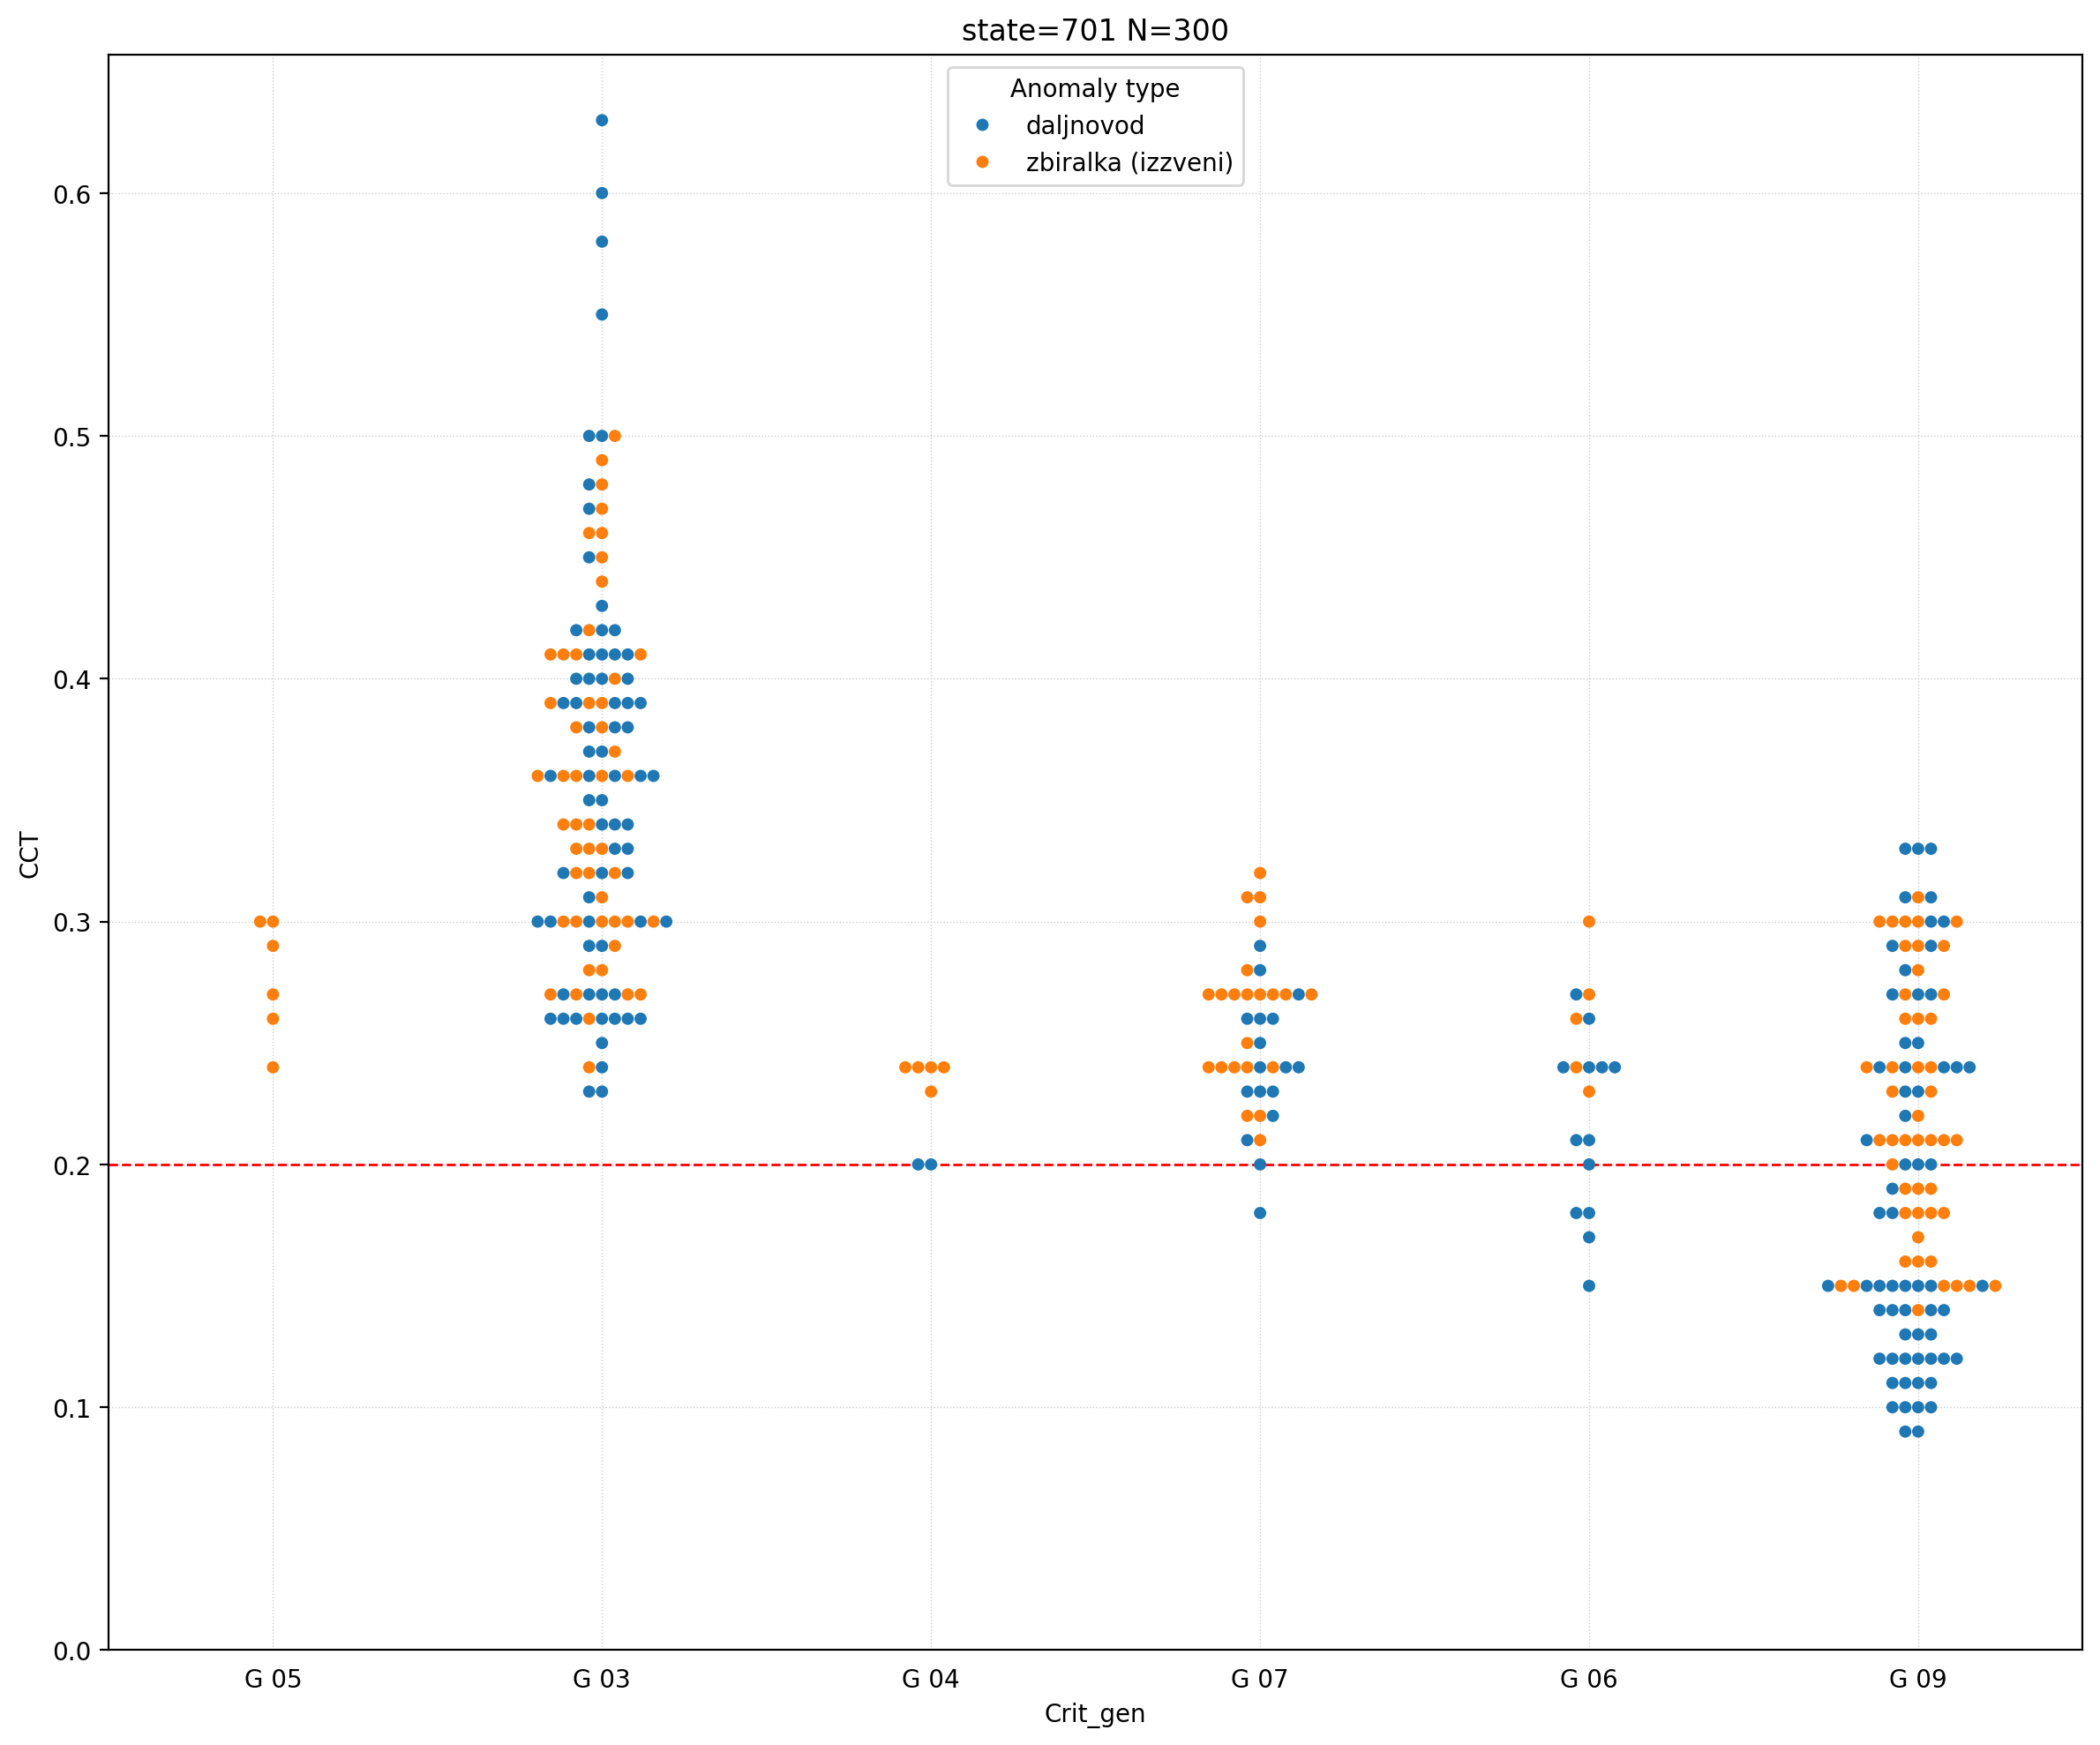

In [ ]:
state_id = 701
state_sample_id = 0

n_samples = 300  # total number of samples for plotting

# in trainset we remove evaluation sample's grid state to avoid potential data leakage.
trainset_mask = df["state"] != state_id

knn = neighbors.NearestNeighbors(
    n_neighbors=n_samples,
    metric="euclidean",
)

with joblib.parallel_backend("loky", n_jobs=joblib.cpu_count()):
    with TimeIt("Feature transformation time"):
        X_train = encoder.transform(df[trainset_mask])
        X_test = encoder.transform(df[~trainset_mask].iloc[[state_sample_id]])

    assert X_test.shape[0] == 1, X_test.shape

    with TimeIt("kNN fit time"):
        knn.fit(X_train)

    with TimeIt("kNN estimate time"):
        distances, indices = knn.kneighbors(X_test, n_neighbors=n_samples, return_distance=True)


# Store distance between already seen samples and a new sample.
neigh = df[trainset_mask].iloc[indices.flatten()].copy()
neigh["distance"] = distances.flatten()


# More verbose type of anomaly used for figures
sc_types = {0: "zbiralka (izzveni)", 1: "daljnovod"}
neigh["Type"] = neigh["Type"].map(sc_types).astype("category")

assert len(neigh) == n_samples, len(neigh)


f, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f"state={state_id} N={len(neigh)}")

# Compute generator order (x-axis) based on minimum CCT per Crit_gen
sorted_order = neigh.groupby("Crit_gen", observed=True)["CCT"].min().sort_values(ascending=False).index

# Add horizontal threshold line
ax.axhline(y=CCT_THRESHOLD, color="red", linestyle="--", linewidth=1)

sns.swarmplot(x="Crit_gen", y="CCT", hue="Type", data=neigh, order=sorted_order, ax=ax, edgecolor="none")

ax.set_ylim(0, None)
ax.grid(which="major", axis="both", linestyle=":", linewidth=0.5, color="0.8")
ax.legend(loc="upper center", title="Anomaly type")
ax.tick_params(axis="x", which="both", bottom=False)

f.tight_layout()
plt.show()

In [ ]:
# Interactive version of UI
import plotly.express as px

fig = px.strip(neigh, x="Crit_gen", y="CCT", color="Type", hover_data=["Location"])
# sns.swarmplot(x="Crit_gen", y="CCT", hue="Type", data=neigh, order=sorted_order, ax=ax, edgecolor="none")
# Compute generator order (x-axis) based on minimum CCT per Crit_gen
sorted_order = neigh.groupby("Crit_gen", observed=True)["CCT"].min().sort_values(ascending=False).index

fig.update_xaxes(categoryorder="array", categoryarray=sorted_order)
fig.update_xaxes()

In [ ]:
with joblib.parallel_backend("loky", n_jobs=joblib.cpu_count()):
    distances, indices = knn.kneighbors(X_test, n_neighbors=X_train.shape[0], return_distance=True)

# Store distance between already seen samples and a new sample.
neigh = df[trainset_mask].iloc[indices.flatten()].copy()
neigh["distance"] = distances.flatten()

# More verbose type of anomaly used for figures
sc_types = {0: "zbiralka (izzveni)", 1: "daljnovod"}
neigh["Type"] = neigh["Type"].map(sc_types).astype("category")

# Is the state stable?
neigh["is_stable"] = neigh["CCT"] > CCT_THRESHOLD

neigh = neigh.sort_values(by="distance")[["state", "Location", "Type", "Crit_gen", "CCT", "is_stable", "distance"]]

In [ ]:
# Identical distance is because different anomaly was simulated on the same grid state.
# This won't be a case in real-world data.
neigh

,state,Location,Type,Crit_gen,CCT,is_stable,distance
1166290,11791,Bus 18,zbiralka (izzveni),G 09,0.29,True,5.898322
316753,11791,Line 03 - 04,daljnovod,G 03,0.43,True,5.898322
338536,11791,Line 04 - 05,daljnovod,G 03,0.42,True,5.898322
360319,11791,Bus 05,zbiralka (izzveni),G 03,0.38,True,5.898322
294970,11791,Bus 04,zbiralka (izzveni),G 03,0.42,True,5.898322
...,...,...,...,...,...,...,...
145938,15240,Line 22 - 23,daljnovod,G 06,1.86,True,49.606530
37023,15240,Line 10 - 13,daljnovod,G 03,1.81,True,49.606530
58806,15240,Line 10 - 11,daljnovod,G 03,1.77,True,49.606530
80589,15240,Bus 19,zbiralka (izzveni),G 04,1.12,True,49.606530


<Axes: ylabel='Frequency'>

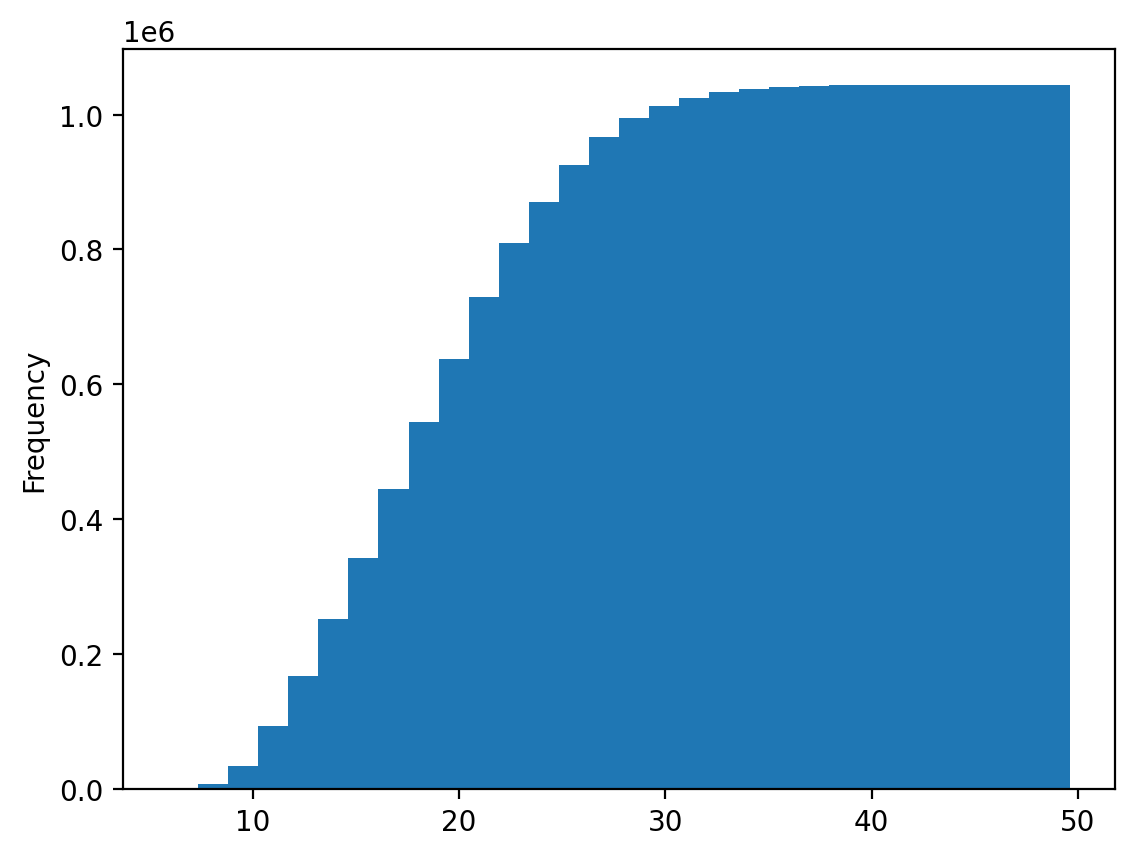

In [ ]:
# Distribution of distances from observed state
neigh["distance"].plot.hist(bins=30, cumulative=True)

In [ ]:
n = 300

for gen, subset in neigh.head(n).groupby("Crit_gen"):
    n_total = len(subset)
    n_stable = subset.is_stable.sum()
    if n_total > 0:
        print(f'Generator "{gen}" stability likelyhood: {n_stable}/{n_total}  ({n_stable / n_total * 100.0:.1f}%)')
    else:
        print(f'Generator "{gen}" stability likelyhood: No Records')

Generator "G 03" stability likelyhood: 116/116  (100.0%)
Generator "G 04" stability likelyhood: 7/7  (100.0%)
Generator "G 05" stability likelyhood: 6/6  (100.0%)
Generator "G 06" stability likelyhood: 15/19  (78.9%)
Generator "G 07" stability likelyhood: 35/36  (97.2%)
Generator "G 08" stability likelyhood: No Records
Generator "G 09" stability likelyhood: 64/116  (55.2%)
Generator "G 10" stability likelyhood: No Records


In [ ]:
# The most hazardous locations (n=500)
n = 500

neigh["Location"].head(n).value_counts()

Location
Line 22 - 23    15
Bus 05           9
Bus 03           9
Bus 08           9
Bus 10           9
Bus 06           9
Bus 07           9
Bus 11           9
Bus 13           9
Bus 17           9
Bus 04           9
Bus 29           9
Bus 28           9
Bus 20           9
Bus 18           9
Bus 21           9
Bus 25           9
Bus 23           9
Bus 22           9
Bus 26           9
Line 06 - 07     9
Line 04 - 14     9
Line 04 - 05     9
Line 02 - 03     9
Line 03 - 18     9
Line 01 - 02     9
Bus 14           9
Line 26 - 27     9
Line 26 - 28     9
Line 26 - 29     9
Line 28 - 29     9
Line 25 - 26     9
Line 23 - 24     9
Line 21 - 22     9
Line 03 - 04     9
Line 10 - 13     9
Line 08 - 09     9
Line 06 - 11     9
Line 07 - 08     9
Line 16 - 17     9
Line 17 - 18     9
Line 13 - 14     9
Line 05 - 08     9
Line 16 - 24     9
Line 14 - 15     8
Line 02 - 25     8
Line 10 - 11     8
Bus 16           8
Bus 24           8
Bus 02           8
Bus 27           8
Line 17 - 27     8
Lin